In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay
from matplotlib import pyplot as plt
from src import *

# 1.0 - Classificação do Desempenho Baseado em Fatores Socioeconômicos Usando Random Forest

In [2]:
colunas = ['Q001','Q002','Q003', 'Q004', 'Q005', 'Q006', 'Q007', 'Q008', 'Q009', 'Q010', 'Q011', 'Q012', 'Q013', 'Q014', 'Q015', 'Q016', 'Q017', 'Q018', 
           'Q019', 'Q020', 'Q021', 'Q022', 'Q023', 'Q024', 'Q025', 'TP_PRESENCA_LC', 'TP_PRESENCA_CH', 'TP_PRESENCA_CN', 'TP_PRESENCA_MT', 
           'TP_FAIXA_ETARIA', 'TP_SEXO','TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_ESCOLA', 'TP_ST_CONCLUSAO', 'IN_TREINEIRO', 
           'NU_ANO', 'TP_LOCALIZACAO_ESC','TP_SIT_FUNC_ESC', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO', 'TP_DEPENDENCIA_ADM_ESC']

df = pd.read_parquet("enem_parquet", columns = colunas)

## 1.1 - Criando uma Amostra

In [3]:
df2 = df.sample(n=1_000_000, random_state=42)

## 1.2 - Limpando os Dados 

In [4]:
FALTOU = (
    (df['TP_PRESENCA_CH'] != 1) | 
    (df['TP_PRESENCA_LC'] != 1) | 
    (df['TP_PRESENCA_CN'] != 1) | 
    (df['TP_PRESENCA_MT'] != 1)
)

df2['FALTOU'] = FALTOU.astype(int)

In [5]:
df = df[df['FALTOU'] == 0]

In [6]:
df = df[df['TP_ESCOLA'].isin([2,3])]
df = df[df['TP_ESTADO_CIVIL'].isin([1,2,3,4])]

In [7]:
df['TP_LOCALIZACAO_ESC'] = df['TP_LOCALIZACAO_ESC'].fillna(0)
df['TP_DEPENDENCIA_ADM_ESC'] = df['TP_DEPENDENCIA_ADM_ESC'].fillna(0)
df['TP_SIT_FUNC_ESC'] = df['TP_SIT_FUNC_ESC'].fillna(0)

In [8]:
df = transformar_colunas_ohe(df)
df = agregar_questionario(df)

In [9]:
df['MEDIA'] = (df['NU_NOTA_CN'] + df['NU_NOTA_CH'] + df['NU_NOTA_MT']+  df['NU_NOTA_LC'] + df['NU_NOTA_REDACAO']) / 5

df['CLASSE'] = df.groupby('NU_ANO')['MEDIA'].transform(lambda x: pd.qcut(x, q=2, labels=[0,1])).astype('Int64')
    
df['CLASSE'] = df['CLASSE'].astype(int)

## 1.3 - Construção da Matriz X e Vetor y

In [10]:
colunas_q_originais = [c for c in df.columns 
                       if c.startswith('Q') and '_' in c]

X = df.drop(
                     columns=['MEDIA', 'CLASSE', 'TP_SEXO', 'TP_COR_RACA',
                     'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 
                     'NU_NOTA_MT', 'NU_NOTA_REDACAO', 'NU_ANO',
                     'TP_LOCALIZACAO_ESC', 'TP_SIT_FUNC_ESC',
                     'TP_PRESENCA_LC', 'TP_PRESENCA_CH',
                     'TP_PRESENCA_CN', 'TP_PRESENCA_MT', 'FALTOU']
                      + colunas_q_originais  
)

y = df['CLASSE']

## 1.4 - Separação em Dados de Treino e Teste

In [11]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 1.5 - Treinando o Modelo

In [12]:
rf = RandomForestClassifier(random_state=42, class_weight='balanced')

rf.fit(x_train, y_train)

print('Ein: %0.4f' % (1 - accuracy_score(y_train, rf.predict(x_train))))
print('Eout: %0.4f' % (1 - accuracy_score(y_test, rf.predict(x_test))))
print(classification_report(y_test, rf.predict(x_test)))

Ein: 0.1118
Eout: 0.3306
              precision    recall  f1-score   support

           0       0.66      0.69      0.67     21851
           1       0.68      0.65      0.66     21848

    accuracy                           0.67     43699
   macro avg       0.67      0.67      0.67     43699
weighted avg       0.67      0.67      0.67     43699



## 1.6 Treinando com os Melhores Parâmetros

In [13]:
cv_rf = tune_random_forest(x_train, y_train, x_test, y_test, n_iter=10, cv=3, scoring='f1_weighted', random_state=42)

print(cv_rf.best_estimator_)
print('Ein:  %0.4f' % (1 - accuracy_score(y_train, cv_rf.predict(x_train))))
print('Eout: %0.4f' % (1 - accuracy_score(y_test,  cv_rf.predict(x_test))))
print(classification_report(y_test, cv_rf.predict(x_test)))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
RandomForestClassifier(class_weight='balanced', max_depth=40,
                       max_features='log2', min_samples_leaf=10,
                       min_samples_split=10, random_state=42)
Ein:  0.2663
Eout: 0.2915
              precision    recall  f1-score   support

           0       0.69      0.76      0.72     21851
           1       0.73      0.66      0.69     21848

    accuracy                           0.71     43699
   macro avg       0.71      0.71      0.71     43699
weighted avg       0.71      0.71      0.71     43699



# 2.0 - Classificação do Desempenho Baseado em Fatores Socioeconômicos Usando Decision Tree

## 2.1 - Criando uma Amostra

In [14]:
df = df.sample(n=10000, random_state=42)

## 2.2 - Construção da Matriz X e Vetor y

In [15]:
colunas_q_originais = [c for c in df.columns 
                       if c.startswith('Q') and '_' in c]

X = df.drop(
                     columns=['MEDIA', 'CLASSE', 'TP_SEXO', 'TP_COR_RACA',
                     'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 
                     'NU_NOTA_MT', 'NU_NOTA_REDACAO', 'NU_ANO',
                     'TP_LOCALIZACAO_ESC', 'TP_SIT_FUNC_ESC',
                     'TP_PRESENCA_LC', 'TP_PRESENCA_CH',
                     'TP_PRESENCA_CN', 'TP_PRESENCA_MT', 'FALTOU']
                      + colunas_q_originais  
)

y = df['CLASSE']

## 2.3 - Separação em Dados de Treino e Teste

In [16]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 2.4 - Treinando o Modelo

In [17]:
clf = DecisionTreeClassifier()
clf.fit(x_train, y_train)

print("Ein: %0.4f" % (1 - accuracy_score(y_train, clf.predict(x_train)) ))
print("Eout: %0.4f" % (1 - accuracy_score(y_test, clf.predict(x_test)) ))

print(classification_report(y_test, clf.predict(x_test)))

Ein: 0.0221
Eout: 0.3790
              precision    recall  f1-score   support

           0       0.62      0.63      0.62      1001
           1       0.62      0.61      0.62       999

    accuracy                           0.62      2000
   macro avg       0.62      0.62      0.62      2000
weighted avg       0.62      0.62      0.62      2000



## 2.5 - Plotando a Árvore

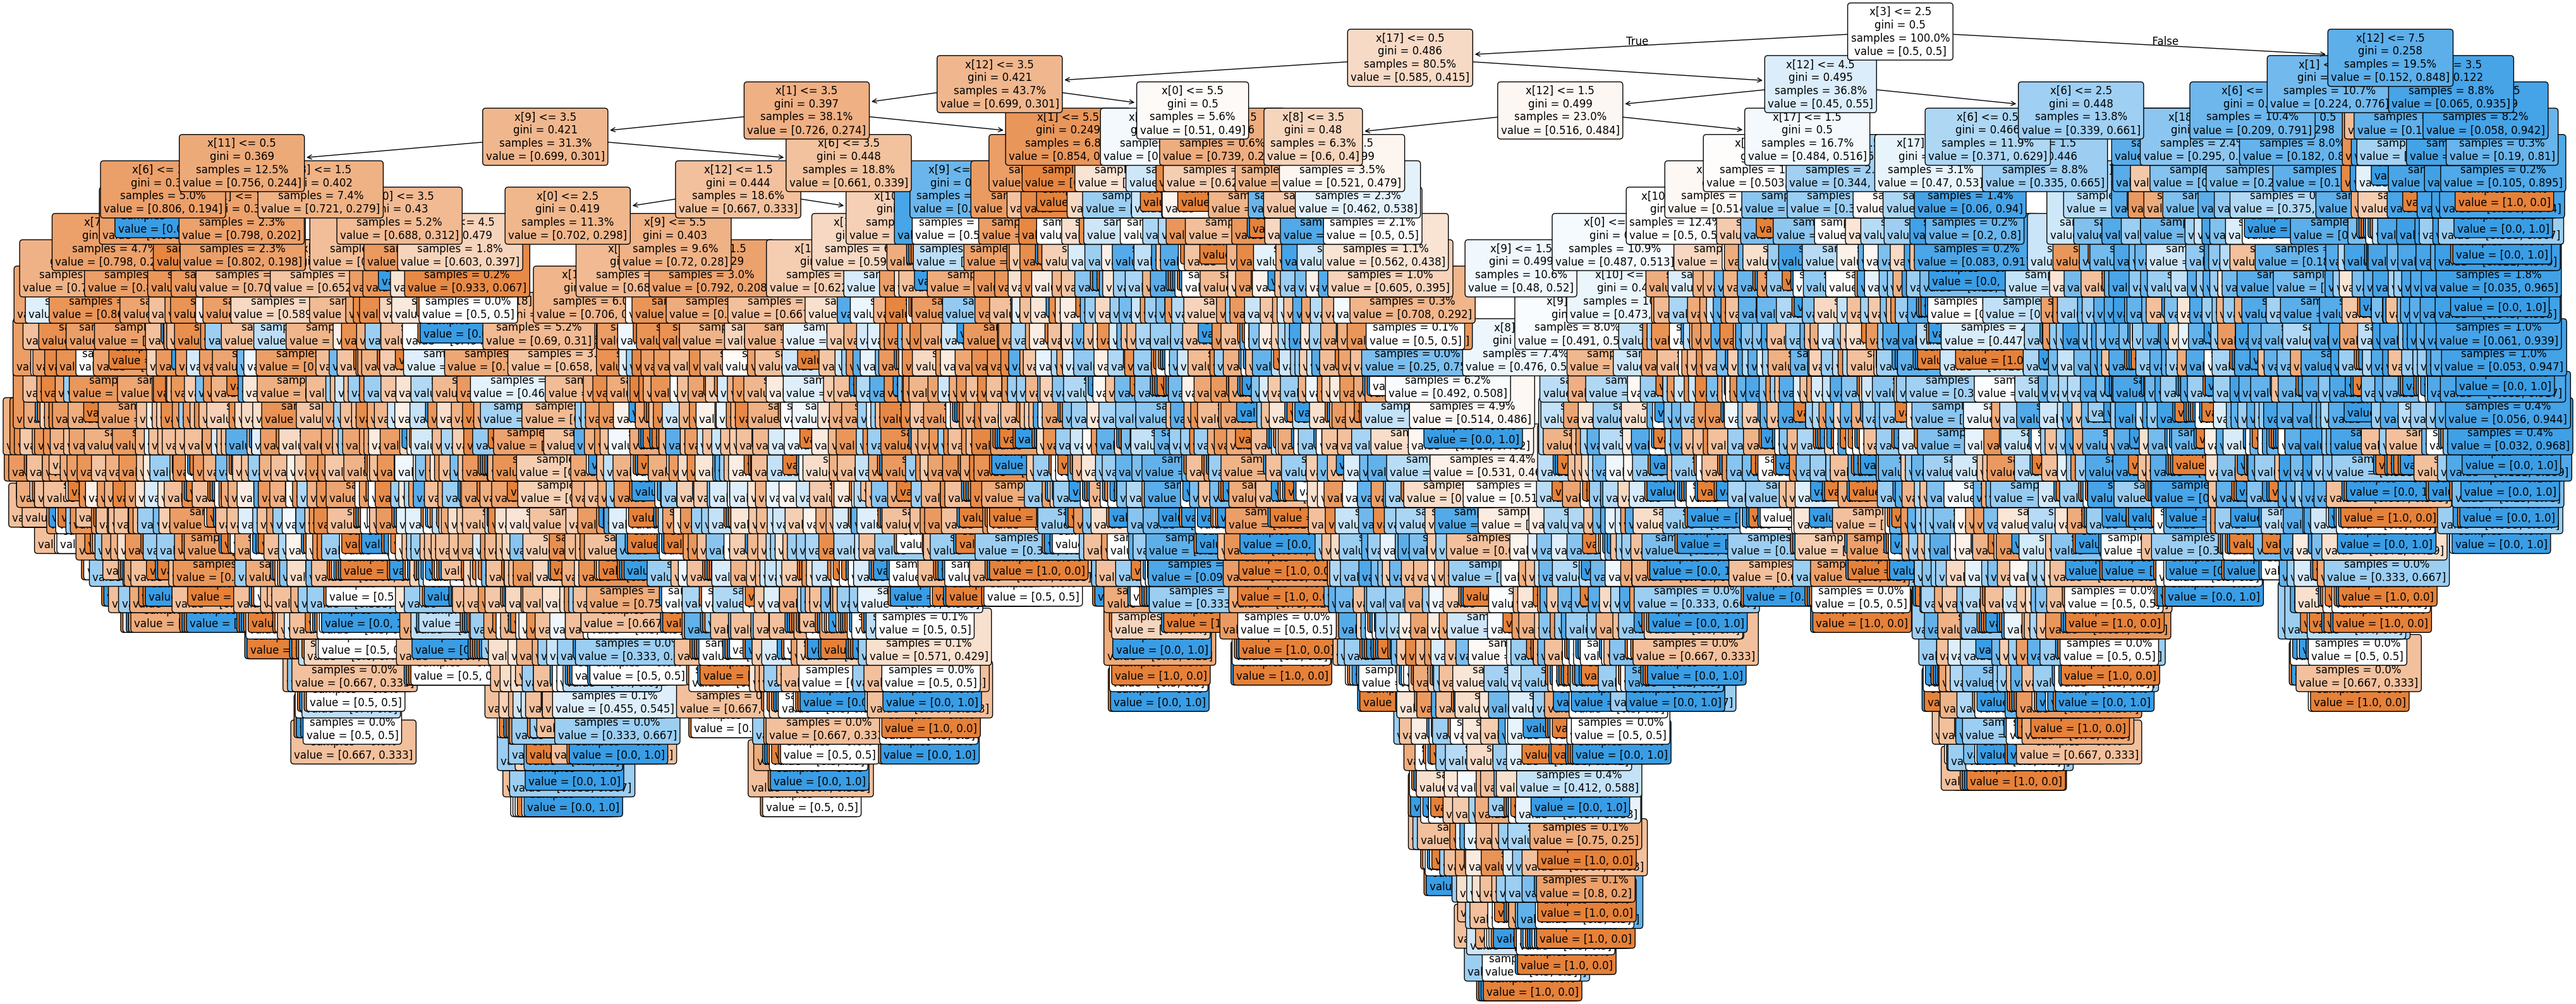

In [18]:
plt.figure(figsize=(50,20))
plot_tree(
    clf,
    filled=True, 
    proportion = True,
    fontsize=12, 
    rounded = True)
plt.show()

## 2.6 - Utilizando o algoritmo de Minimal Cost-Complexity

C:\Users\Micael\AppData\Local\Temp\ipykernel_17160\3411306458.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


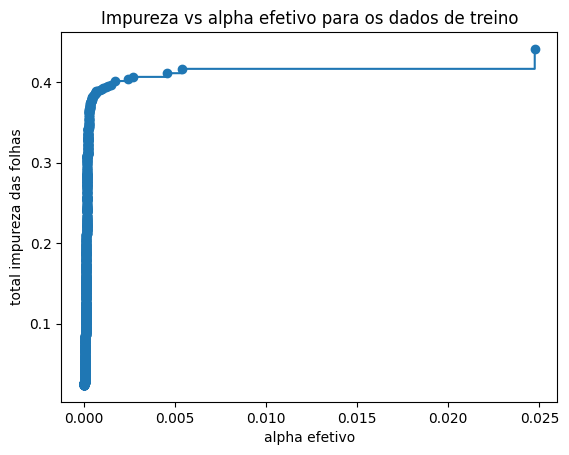

In [19]:
path = clf.cost_complexity_pruning_path(x_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

fig, ax = plt.subplots()
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("alpha efetivo")
ax.set_ylabel("total impureza das folhas")
ax.set_title("Impureza vs alpha efetivo para os dados de treino")
fig.show()

## 2.7 - Regularizar o alpha com Minimal Cost-Complexity via cross-validation

In [20]:
alphas_reduzidos = np.unique(np.quantile(path.ccp_alphas, np.linspace(0, 1, 200)))
param_grid = {'ccp_alpha': alphas_reduzidos}

CV_clf = GridSearchCV(estimator=clf, param_grid=param_grid, cv = 5, verbose=2, n_jobs=-1)

CV_clf.fit(x_train, y_train)


print('Ein: %0.4f' % (1 - accuracy_score(y_train, CV_clf.predict(x_train))))
print('Eout: %0.4f' % (1 - accuracy_score(y_test, CV_clf.predict(x_test))))
print(classification_report(y_test, CV_clf.predict(x_test)))

Fitting 5 folds for each of 166 candidates, totalling 830 fits
Ein: 0.2939
Eout: 0.2995
              precision    recall  f1-score   support

           0       0.71      0.68      0.69      1001
           1       0.69      0.72      0.71       999

    accuracy                           0.70      2000
   macro avg       0.70      0.70      0.70      2000
weighted avg       0.70      0.70      0.70      2000

